In [1]:
# Import the required library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
A=pd.read_excel("Restaurent data.xlsx")
B=pd.read_excel('Country-Code.xlsx')
data=pd.merge(A,B)
data

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498,Indonesia
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873,Indonesia
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605,Indonesia
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395,Indonesia
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243,Indonesia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,17582627,Senor Iguanas,216,Pocatello,"961 Hiline Rd, Pocatello, ID 83201",Pocatello,"Pocatello, Pocatello",-112.443300,42.894200,Mexican,0,Dollar($),No,No,1,3.6,Yellow,Good,108,United States
9547,16654702,Lake House Restaurant,37,Vineland Station,"3100 N Service Rd, Vineland Station, ON L0R2E0",Vineland Station,"Vineland Station, Vineland Station",-79.379147,43.186870,"Italian, Mediterranean, Pizza",70,Dollar($),No,No,4,4.3,Green,Very Good,204,Canada
9548,16659169,Tokyo Sushi,37,Chatham-Kent,"150 Richmond St, Chatham-Kent, ON N7M2V2",Chatham-Kent,"Chatham-Kent, Chatham-Kent",-82.188438,42.397683,"Japanese, Sushi",25,Dollar($),No,No,2,3.7,Yellow,Good,176,Canada
9549,16643459,Consort Restaurant,37,Consort,"4931 50th Street, Consort, AB T0C 1B0",Consort,"Consort, Consort",-110.774699,52.008289,"Chinese, Canadian",25,Dollar($),No,No,2,3.0,Orange,Average,6,Canada


In [3]:
data.shape

(9551, 20)

In [4]:
data.isnull().sum()

Restaurant ID           0
Restaurant Name         1
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Country                 0
dtype: int64

In [5]:
data.dropna(inplace=True)

In [6]:
df = data.groupby(['City','Restaurant Name']).agg( Count = ('Restaurant Name','count'))
df.sort_values(by='Count',ascending=False)

Count
City      Restaurant Name                
New Delhi Cafe Coffee Day              57
          Domino's Pizza               55
          Subway                       38
          Green Chick Chop             37
          McDonald's                   33
...                                   ...
          Bhashi Caterers               1
          Bhasad Cafe                   1
          Bhardwaj Bakery               1
          Bharat Sweet House            1
€¡stanbul Walter's Coffee Roastery      1

[7964 rows x 1 columns]

In [7]:
resto1 =df[df['Count']==1]
resto1

Count
City      Restaurant Name                        
Abu Dhabi Applebee's                            1
          Bait El Khetyar                       1
          Cho Gao - Crowne Plaza Abu Dhabi      1
          Denny's                               1
          Famous Dave's Barbecue                1
...                                           ...
€¡stanbul Leman KÌ_ltÌ_r                        1
          Naml€± Gurme                          1
          Starbucks                             1
          Valonia                               1
          Walter's Coffee Roastery              1

[7321 rows x 1 columns]

In [8]:

df1 = data.groupby(['Restaurant Name','Country']).agg( Count = ('Country','count'))
df1.sort_values(by='Count',ascending=False)

,,Count
Restaurant Name,Country,
Cafe Coffee Day,India,83
Domino's Pizza,India,79
Subway,India,63
Green Chick Chop,India,51
McDonald's,India,48
...,...,...
Giapo,New Zealand,1
Giani's di Hatti,India,1
Gian Ji Punjabi Dhaba,India,1


In [9]:
dummy = ['Has Table booking','Has Online delivery']
data = pd.get_dummies(data,columns=dummy,drop_first=True)


In [10]:
data.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Price range,Aggregate rating,Rating color,Rating text,Votes,Country,Has Table booking_Yes,Has Online delivery_Yes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),3,4.1,Green,Very Good,1498,Indonesia,0,0
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),3,4.6,Dark Green,Excellent,873,Indonesia,0,0
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),3,4.9,Dark Green,Excellent,605,Indonesia,0,0
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),3,4.2,Green,Very Good,395,Indonesia,0,0
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),3,4.3,Green,Very Good,243,Indonesia,0,0


In [11]:
data['Has Table booking_Yes'].value_counts()
# 0 indicates 'NO'
# 1 indicates 'YES'

0    8383
1    1158
Name: Has Table booking_Yes, dtype: int64

In [12]:

a=(data[data['Has Table booking_Yes']==1]['Restaurant ID']).count()
b=(data[data['Has Table booking_Yes']==0]['Restaurant ID']).count()
a

1158

In [13]:
b

8383

In [14]:
ratio=round((a/b),2)

In [15]:
ratio

0.14

In [16]:
print('ratio between restaurants that allow table booking vs do not allow tablebooking is',ratio)

ratio between restaurants that allow table booking vs do not allow tablebooking is 0.14


# percentage of restaurants providing online delivery

In [17]:
a1=(data[data['Has Online delivery_Yes']==1]['Restaurant ID']).count()
b1=(data[data['Has Online delivery_Yes']==0]['Restaurant ID']).count()
a1

2451

In [18]:
b1

7090

In [19]:
Ratio=round((a1/b1),2)*100

In [20]:
print('percentage of restaurants providing online delivery is',Ratio)

percentage of restaurants providing online delivery is 35.0


# the difference in number of votes for the restaurants that deliver and the restaurants that do not deliver

 

In [21]:
diff=(data[data['Has Online delivery_Yes']==0]['Votes']).count()-(data[data['Has Online delivery_Yes']==1]['Votes']).count()
diff

4639

In [22]:
data.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Price range', 'Aggregate rating',
       'Rating color', 'Rating text', 'Votes', 'Country',
       'Has Table booking_Yes', 'Has Online delivery_Yes'],
      dtype='object')

# What are the top 10 cuisines served across cities?

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9541 entries, 0 to 9550
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Restaurant ID            9541 non-null   int64  
 1   Restaurant Name          9541 non-null   object 
 2   Country Code             9541 non-null   int64  
 3   City                     9541 non-null   object 
 4   Address                  9541 non-null   object 
 5   Locality                 9541 non-null   object 
 6   Locality Verbose         9541 non-null   object 
 7   Longitude                9541 non-null   float64
 8   Latitude                 9541 non-null   float64
 9   Cuisines                 9541 non-null   object 
 10  Average Cost for two     9541 non-null   int64  
 11  Currency                 9541 non-null   object 
 12  Price range              9541 non-null   int64  
 13  Aggregate rating         9541 non-null   float64
 14  Rating color            

In [24]:
data['Cuisines']=data['Cuisines'].astype('str')


In [25]:
data.dtypes

Restaurant ID                int64
Restaurant Name             object
Country Code                 int64
City                        object
Address                     object
Locality                    object
Locality Verbose            object
Longitude                  float64
Latitude                   float64
Cuisines                    object
Average Cost for two         int64
Currency                    object
Price range                  int64
Aggregate rating           float64
Rating color                object
Rating text                 object
Votes                        int64
Country                     object
Has Table booking_Yes        uint8
Has Online delivery_Yes      uint8
dtype: object

In [26]:
cuisines = data['Cuisines'].apply(lambda x: pd.Series(x.split(',')))

In [27]:
cuisines.columns = ['Cuisine_1','Cuisine_2','Cuisine_3','Cuisine_4','Cuisine_5','Cuisine_6','Cuisine_7','Cuisine_8']
cuisines.head()

,Cuisine_1,Cuisine_2,Cuisine_3,Cuisine_4,Cuisine_5,Cuisine_6,Cuisine_7,Cuisine_8
0,Italian,Continental,NaN,NaN,NaN,NaN,NaN,NaN
1,Asian,Indonesian,Western,NaN,NaN,NaN,NaN,NaN
2,Sushi,Japanese,NaN,NaN,NaN,NaN,NaN,NaN
3,Japanese,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,French,Western,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
data_cuisines = pd.concat([data,cuisines],axis=1)
data_cuisines.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking_Yes,Has Online delivery_Yes,Cuisine_1,Cuisine_2,Cuisine_3,Cuisine_4,Cuisine_5,Cuisine_6,Cuisine_7,Cuisine_8
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",...,0,0,Italian,Continental,NaN,NaN,NaN,NaN,NaN,NaN
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",...,0,0,Asian,Indonesian,Western,NaN,NaN,NaN,NaN,NaN
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",...,0,0,Sushi,Japanese,NaN,NaN,NaN,NaN,NaN,NaN
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,...,0,0,Japanese,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",...,0,0,French,Western,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
cuisine_loc = pd.DataFrame(data_cuisines[['Country','City','Cuisine_1','Cuisine_2','Cuisine_3',
                                        'Cuisine_4','Cuisine_5','Cuisine_6','Cuisine_7','Cuisine_8','Restaurant ID']])

In [30]:
cuisine_loc_stack=pd.DataFrame(cuisine_loc.stack()) #stacking the columns 
cuisine_loc.head()

,Country,City,Cuisine_1,Cuisine_2,Cuisine_3,Cuisine_4,Cuisine_5,Cuisine_6,Cuisine_7,Cuisine_8,Restaurant ID
0,Indonesia,Jakarta,Italian,Continental,NaN,NaN,NaN,NaN,NaN,NaN,7402935
1,Indonesia,Jakarta,Asian,Indonesian,Western,NaN,NaN,NaN,NaN,NaN,7410290
2,Indonesia,Jakarta,Sushi,Japanese,NaN,NaN,NaN,NaN,NaN,NaN,7420899
3,Indonesia,Jakarta,Japanese,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7421967
4,Indonesia,Jakarta,French,Western,NaN,NaN,NaN,NaN,NaN,NaN,7422489


In [31]:
df2 = cuisine_loc.groupby(['City','Cuisine_1','Cuisine_2','Cuisine_3','Cuisine_4',
    'Cuisine_5','Cuisine_6','Cuisine_7','Cuisine_8']).agg( Count = ('Restaurant ID','count'))

In [32]:
df2.value_counts()


Count
1        8
6        1
dtype: int64

In [33]:
data.head(1)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Price range,Aggregate rating,Rating color,Rating text,Votes,Country,Has Table booking_Yes,Has Online delivery_Yes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),3,4.1,Green,Very Good,1498,Indonesia,0,0


# What is the maximum and minimum number of cuisines that a restaurant serves? Also, which is the most served cuisine across the restaurant for each city?

In [34]:
df3 = data.groupby(['Restaurant Name','Cuisines']).agg( Count = ('Restaurant ID','count'))
df3.sort_values(by='Count',ascending=False)

,,Count
Restaurant Name,Cuisines,
Cafe Coffee Day,Cafe,83
Domino's Pizza,"Pizza, Fast Food",78
Subway,"American, Fast Food, Salad, Healthy Food",62
Green Chick Chop,"Raw Meats, North Indian, Fast Food",47
McDonald's,"Fast Food, Burger",44
...,...,...
Fusilli Reasons,Italian,1
Funkey Monkey,"Breakfast, Coffee and Tea",1
Funk House Cafe,"Cafe, Italian, Salad",1


In [35]:
df4 = data.groupby(['City','Restaurant Name','Cuisines']).agg( Count = ('Restaurant ID','count'))
df4=df4.sort_values(by='Count',ascending=False)

# What is the distribution cost across the restaurants? 

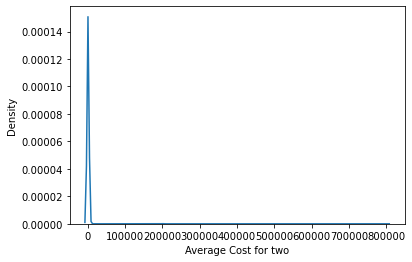

In [36]:
sns.kdeplot(data['Average Cost for two'])
plt.show()

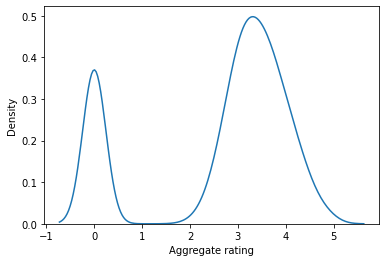

In [37]:
sns.kdeplot(data['Aggregate rating'])
plt.show()

In [38]:
data.corr()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes,Has Table booking_Yes,Has Online delivery_Yes
Restaurant ID,1.000000,0.146246,-0.224353,-0.052657,-0.001631,-0.134407,-0.327092,-0.147306,-0.109840,-0.084683
Country Code,0.146246,1.000000,-0.694627,0.018041,0.043716,0.245429,0.281340,0.154423,-0.060827,-0.153603
Longitude,-0.224353,-0.694627,1.000000,0.045421,0.045949,-0.080292,-0.114759,-0.084410,0.099869,0.177938
Latitude,-0.052657,0.018041,0.045421,1.000000,-0.111081,-0.166716,0.000222,-0.022879,0.054864,0.119074
Average Cost for two,-0.001631,0.043716,0.045949,-0.111081,1.000000,0.075121,0.051869,0.067844,0.007732,-0.019019
Price range,-0.134407,0.245429,-0.080292,-0.166716,0.075121,1.000000,0.438286,0.309339,0.502267,0.077976
Aggregate rating,-0.327092,0.281340,-0.114759,0.000222,0.051869,0.438286,1.000000,0.313381,0.190398,0.226323
Votes,-0.147306,0.154423,-0.084410,-0.022879,0.067844,0.309339,0.313381,1.000000,0.169693,0.074629
Has Table booking_Yes,-0.109840,-0.060827,0.099869,0.054864,0.007732,0.502267,0.190398,0.169693,1.000000,0.101021
Has Online delivery_Yes,-0.084683,-0.153603,0.177938,0.119074,-0.019019,0.077976,0.226323,0.074629,0.101021,1.000000


In [39]:
data.to_excel('Output.xlsx',index=False)

